## Session 18 - Optional Task (WineQuality Dataset)

# WineQT Dataset - Complete Data Analysis and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv("WineQT.csv")

# Display first 10 rows
print("First 10 Rows:")
print(df.head(10))

# Display last 5 rows
print("\nLast 5 Rows:")
print(df.tail())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display dataset information
print("\nDataset Information:")
df.info()

First 10 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   
5            7.4              0.66         0.00             1.8      0.075   
6            7.9              0.60         0.06             1.6      0.069   
7            7.3              0.65         0.00             1.2      0.065   
8            7.8              0.58         0.02             2.0      0.073   
9            6.7              0.58         0.08             1.8      0.097   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.997

In [3]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("\nDuplicate Rows:", duplicate_count)

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDuplicate Rows After Removal:")
print(df.duplicated().sum())

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Duplicate Rows: 0

Duplicate Rows After Removal:
0


In [4]:
# Display statistical summary
print("Statistical Summary:")
print(df.describe())

columns = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "alcohol",
    "quality"
]

for col in columns:
    print(f"\n{col.upper()} Statistics")
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())
    print("Mean    :", df[col].mean())
    print("Median  :", df[col].median())

Statistical Summary:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000         

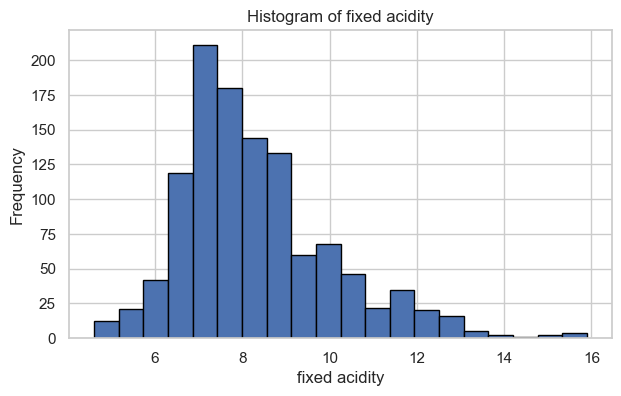

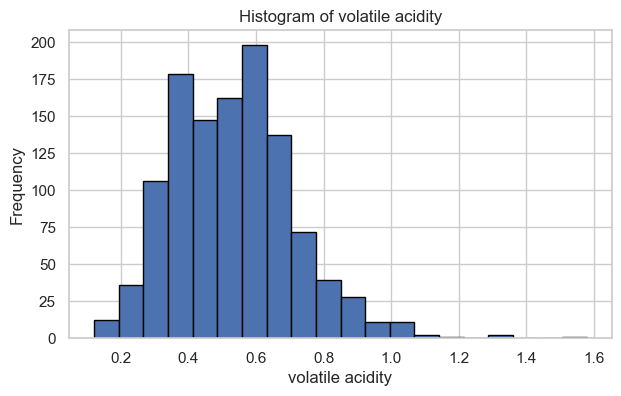

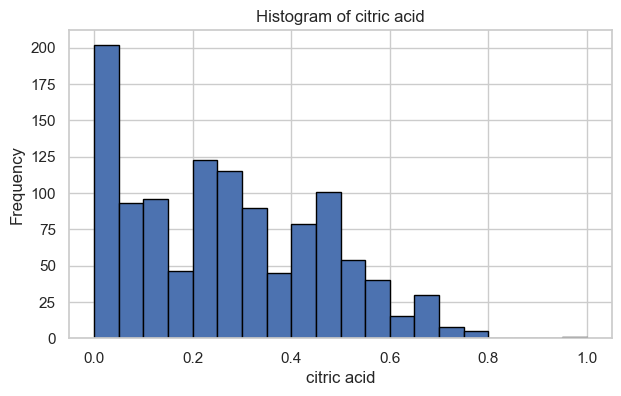

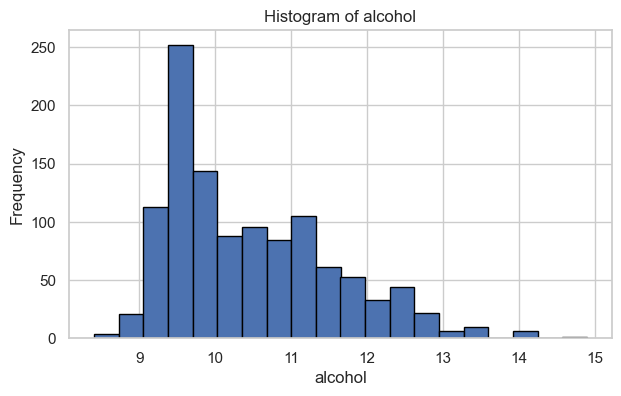

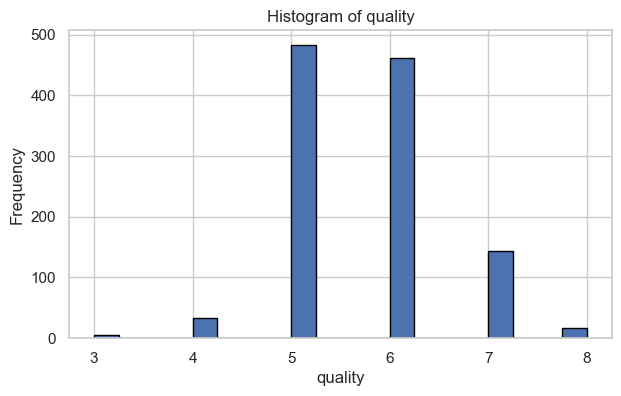

In [5]:
numeric_columns = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "alcohol",
    "quality"
]

for col in numeric_columns:

    plt.figure(figsize=(7,4))

    plt.hist(df[col], bins=20, edgecolor="black")

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

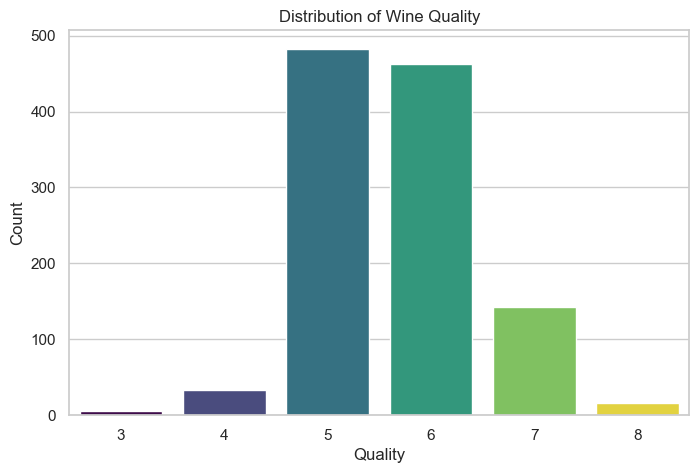

In [6]:
# Count plot of wine quality

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="quality",
    hue="quality",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")

plt.show()

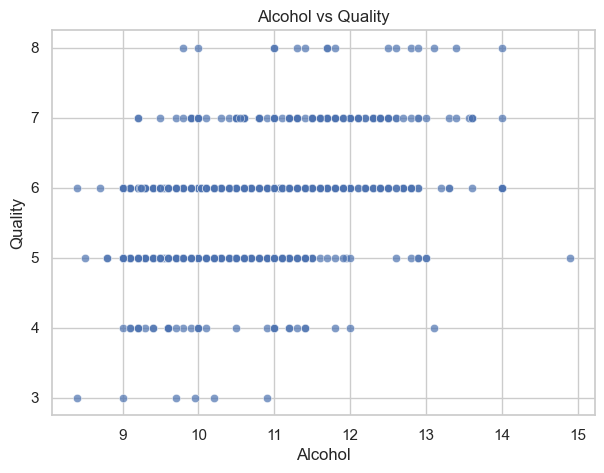

In [7]:
# Scatter plot between Alcohol and Quality

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="alcohol",
    y="quality",
    alpha=0.7
)

plt.title("Alcohol vs Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")

plt.show()

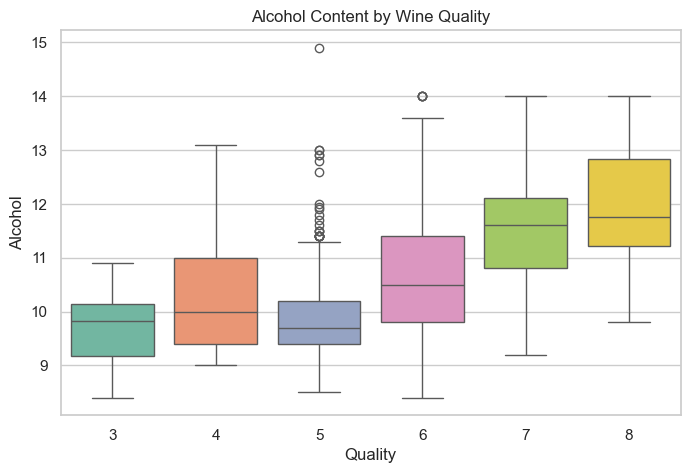

In [13]:
# Box plot of Alcohol by Quality
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="quality",
    y="alcohol",
    hue="quality",
    palette="Set2",
    legend=False
)

plt.title("Alcohol Content by Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")

plt.show()

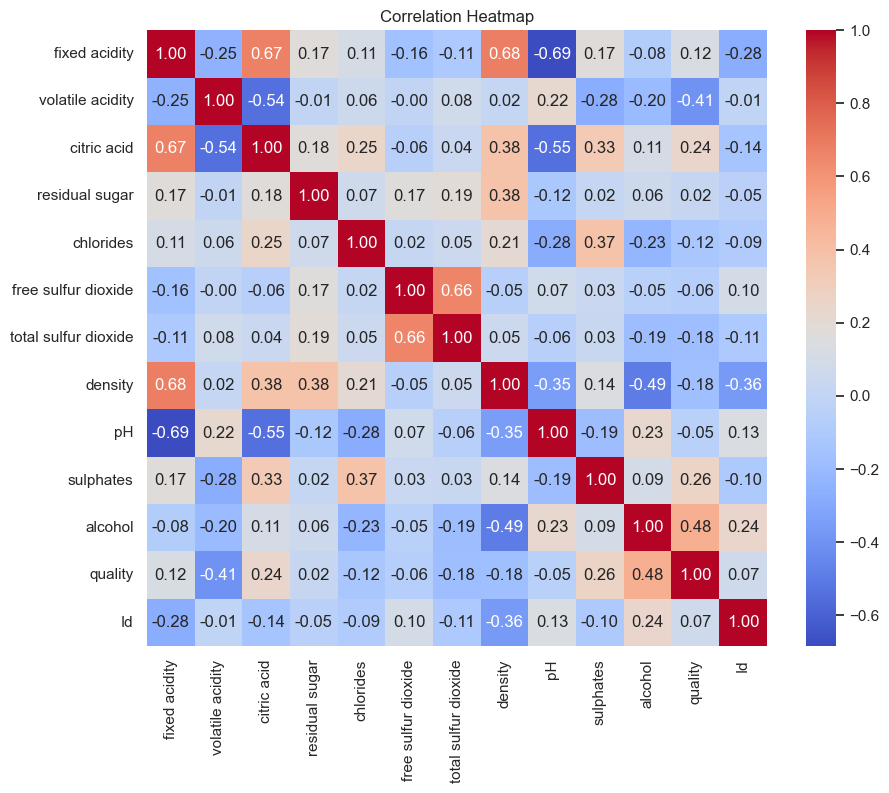

Correlation with Quality:
quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


In [9]:
# Select numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Correlation with target variable
print("Correlation with Quality:")
print(corr_matrix["quality"].sort_values(ascending=False))

In [10]:
# Independent Features
X = df.drop("quality", axis=1)

# Remove Id column if present
if "Id" in X.columns:
    X = X.drop("Id", axis=1)

# Dependent Feature
y = df["quality"]

print("Independent Features:")
print(X.columns.tolist())

print("\nDependent Feature:")
print(y.name)

Independent Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Dependent Feature:
quality


In [11]:
from sklearn.preprocessing import StandardScaler

# Apply Standard Scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(X)

# Convert scaled data to DataFrame
scaled_df = pd.DataFrame(
    scaled_data,
    columns=X.columns
)

print("First 5 Rows of Scaled Data:")
print(scaled_df.head())

First 5 Rows of Scaled Data:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.521580          0.939332    -1.365027       -0.466421  -0.231395   
1      -0.292593          1.941813    -1.365027        0.050060   0.234247   
2      -0.292593          1.273492    -1.161568       -0.171289   0.107253   
3       1.653789         -1.399789     1.483400       -0.466421  -0.252560   
4      -0.521580          0.939332    -1.365027       -0.466421  -0.231395   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -0.450467             -0.363610  0.555854  1.270695  -0.573658   
1             0.915920              0.643477  0.036165 -0.708928   0.130881   
2            -0.060071              0.246745  0.140103 -0.325775  -0.045254   
3             0.135127              0.429852  0.659792 -0.964363  -0.456235   
4            -0.450467             -0.363610  0.555854  1.270695  -0.573658   

    alcohol  
0 -0.963382  

In [12]:
from sklearn.preprocessing import StandardScaler

# Remove duplicate rows
df = df.drop_duplicates()

# Define input and output features
X = df.drop("quality", axis=1)

# Remove Id column if present
if "Id" in X.columns:
    X = X.drop("Id", axis=1)

y = df["quality"]

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Preprocessed Features:")
print(X_scaled.head())

print("\nTarget Variable:")
print(y.head())

print("\nPreprocessing completed successfully.")

Preprocessed Features:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.521580          0.939332    -1.365027       -0.466421  -0.231395   
1      -0.292593          1.941813    -1.365027        0.050060   0.234247   
2      -0.292593          1.273492    -1.161568       -0.171289   0.107253   
3       1.653789         -1.399789     1.483400       -0.466421  -0.252560   
4      -0.521580          0.939332    -1.365027       -0.466421  -0.231395   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -0.450467             -0.363610  0.555854  1.270695  -0.573658   
1             0.915920              0.643477  0.036165 -0.708928   0.130881   
2            -0.060071              0.246745  0.140103 -0.325775  -0.045254   
3             0.135127              0.429852  0.659792 -0.964363  -0.456235   
4            -0.450467             -0.363610  0.555854  1.270695  -0.573658   

    alcohol  
0 -0.963382  
1 -0.

### Summary

• **Dataset Overview**

* Explored the WineQT dataset containing various physicochemical properties of wine and their corresponding quality ratings.
* The dataset consists mainly of numerical features used to evaluate wine quality.

• **Data Exploration**

* Loaded and explored the dataset.
* Checked the shape, columns, and data types.

• **Data Cleaning**

* Checked for missing values and duplicate records.
* Verified the dataset was clean and ready for analysis.

• **Data Analysis**

* Generated summary statistics.
* Created histograms, a count plot, a scatter plot, a box plot, and a correlation heatmap.
* Analyzed the relationship between different wine properties and quality.

• **Preprocessing**

* Identified the input and target features.
* Applied Standard Scaling to the numerical features.

• **Key Learning**

* Learned the complete data preprocessing workflow for a wine quality dataset.
* Understood how different physicochemical properties influence wine quality.
* Prepared the dataset for machine learning analysis.

### Note

The WineQT dataset contains only numerical features (apart from an optional **Id** column), so **One Hot Encoding** or **Label Encoding** is not required. The target variable is **quality**, which is already numeric.
